**Imports**

In [1]:
import os
import logging
import requests
from dotenv import load_dotenv
from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from pptx import Presentation
import matplotlib.dates as mdates
import re

**Setup**

In [2]:
# Working directory
project_root = Path("/home/gm/Documents/Projects/automated-company-profile-deck")
os.chdir(project_root)

# Environment variables
load_dotenv()
mistral_api_key = os.getenv("MISTRAL_API_KEY")

# Paths
template_path = "templates/deck.pptx"

# Logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)

# Presentation
prs = Presentation(template_path)

**Variables**

In [3]:
# Stock data
symbol = "BA"
current_date = datetime.now()
output_path = f"output/{symbol}_{current_date.strftime('%d-%m-%Y')}.pptx"
ticker = yf.Ticker(symbol)

**Functions**

In [4]:
# Formatting
def format_number(value):
    """Format a number with appropriate suffix (T, B, M, K). Returns 'N/A' if None."""
    if value is None:
        return "N/A"
    if abs(value) >= 1e12:
        return f"{value / 1e12:.1f}T"
    elif abs(value) >= 1e9:
        return f"{value / 1e9:.1f}B"
    elif abs(value) >= 1e6:
        return f"{value / 1e6:.1f}M"
    elif abs(value) >= 1e3:
        return f"{value / 1e3:.1f}K"
    else:
        return f"{value:,.0f}"

def format_currency(value):
    """Format a number as currency. Returns 'N/A' if None."""
    if value is None:
        return "N/A"
    return f"{value:,.1f}"

def format_percentage(value):
    """Format a number as percentage. Returns 'N/A' if None."""
    if value is None:
        return "N/A"
    return f"{value * 100:.1f}%"


# Mistral API
def mistral_api_call(messages, model="mistral-tiny", temperature=0.1, max_tokens=100, api_key=None):
    
    api_key = mistral_api_key
    
    api_url = "https://api.mistral.ai/v1/chat/completions"
    headers = {"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"}
    payload = {
        "model": model,
        "messages": messages,
        "temperature": temperature,
        "max_tokens": max_tokens
    }

    try:
        response = requests.post(api_url, headers=headers, json=payload)
        response.raise_for_status()
        return response.json()["choices"][0]["message"]["content"].strip()
    except Exception as e:
        return f"Error: {str(e)}"

### Slide #1

**Data**

In [5]:
# Data
info = ticker.info

company_name     = info.get("displayName", "N/A")
company_ticker   = info.get("symbol", "N/A")
company_sector   = info.get("sector", "N/A")
company_industry = info.get("industry", "N/A")
market_cap       = format_number(info.get("marketCap", 0))
share_price      = format_currency(info.get("currentPrice", 0))
share_earnings   = format_currency(info.get("trailingEps", 0))
analyst_rating   = info.get("averageAnalystRating", "N/A")
beta             = info.get("beta", "N/A")
ltm_revenue      = format_number(info.get("totalRevenue", "N/A"))
revenue_growth   = format_percentage(info.get("revenueGrowth", 0))
ltm_ebitda       = format_number(info.get("ebitda", 0))
ebitda_margin    = format_percentage(info.get("ebitdaMargins", 0))

description      = info.get("longBusinessSummary", "N/A")
response = mistral_api_call(
    messages=[{
        "role": "user",
        "content": f"Act as an equity research analyst. Provide ONLY a strictly 50-words or fewer summary of the business of {company_name}. Do not include any headers, titles, prefixes, or the word 'Summary'. Description: {description}"
    }],
    max_tokens=200
)

summary = re.sub(r'[*_~`\[\]]', '', response)

**Edit**

In [6]:
slide = prs.slides[1]

text_fields = {
    "name": str(company_name),
    "symbol": str(company_ticker),
    "sector": str(company_sector),
    "industry": str(company_industry),
    "market_cap": str(market_cap),
    "earnings": str(share_earnings),
    "stock_price": str(share_price),
    "analyst_rating": str(analyst_rating),
    "beta": str(beta),
    "description": str(summary),
    "ltm_revenue": str(ltm_revenue),
    "revenue_growth": str(revenue_growth),
    "ltm_ebitda": str(ltm_ebitda),
    "ebitda_margin": str(ebitda_margin)
}

for shape in slide.shapes:
    if shape.name in text_fields and shape.has_text_frame:
        paragraph = shape.text_frame.paragraphs[0]
        if paragraph.runs:
            paragraph.runs[0].text = text_fields[shape.name]
        else:
            paragraph.add_run().text = text_fields[shape.name]

prs.save(output_path)

### Slide #2

**Data**

In [7]:
data = ticker.history(period = "6mo", interval = "1d")

p_current = data["Close"].iloc[-1]
p_mean    = data["Close"].mean()
p_max     = data["Close"].max()
p_min     = data["Close"].min()
p_75q     = data["Close"].quantile(0.75)
p_50q     = data["Close"].quantile(0.5)
p_25q     = data["Close"].quantile(0.25)
p_std     = data["Close"].std()
p_analyst = ticker.info.get("targetMeanPrice", 0)

**Chart**

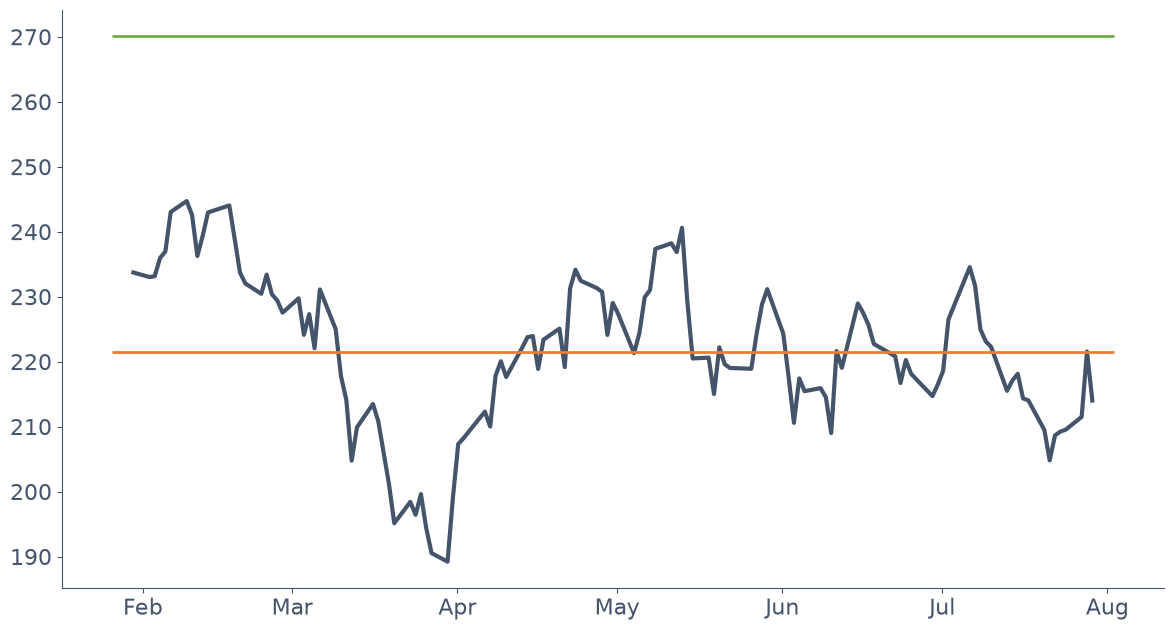

In [8]:
plt.figure(figsize=(11.84, 6.40))
sns.lineplot(data["Close"], linewidth=3, color = "#44546A")
plt.rcParams['font.family'] = ['Arial', 'sans-serif']
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#44546A')
plt.gca().spines['bottom'].set_color('#44546A')
plt.tick_params(axis='both', labelsize=16, colors='#44546A')
plt.gca().set(xlabel=None, ylabel=None)
plt.tick_params(axis='both', labelsize=16)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

x_min, x_max = plt.gca().get_xlim()

plt.hlines(y=p_mean,
           xmin=x_min + 0.025*(x_max - x_min),
           xmax=x_max - 0.025*(x_max - x_min),
           color="#ED7D31",
           linestyle='-',
           linewidth=2,
           label="Mean price")

plt.hlines(y=p_analyst,
           xmin=x_min + 0.025*(x_max - x_min),
           xmax=x_max - 0.025*(x_max - x_min),
           color="#70AD47",
           linestyle='-',
           linewidth=2,
           label="Analyst expectation")

plt.tight_layout()
plt.savefig("output/price_chart.png", dpi=200, bbox_inches='tight')

**Edit**

In [9]:
slide = prs.slides[2]

# Replace chart
for shape in slide.shapes:
    if shape.name == "price_chart":
        image_path = "output/price_chart.png"
        left = shape.left
        top = shape.top
        width = shape.width
        height = shape.height
        shape.element.getparent().remove(shape.element)
        slide.shapes.add_picture(
            str(image_path),
            left,
            top,
            width=width,
            height=height
        )
        break

# Replace text fields
text_fields = {
    "current_price": f"{p_current:.0f}",
    "mean_price": f"{p_mean:.0f}",
    "max_price": f"{p_max:.0f}",
    "q75_price": f"{p_75q:.0f}",
    "q50_price": f"{p_50q:.0f}",
    "q25_price": f"{p_25q:.0f}",
    "min_price": f"{p_min:.0f}",
    "std_price": f"{p_std:.0f}",
    "analyst_expectation": f"{p_analyst:.0f}"
}

for shape in slide.shapes:
    if shape.name in text_fields and shape.has_text_frame:
        paragraph = shape.text_frame.paragraphs[0]
        if paragraph.runs:
            paragraph.runs[0].text = text_fields[shape.name]
        else:
            paragraph.add_run().text = text_fields[shape.name]

prs.save(output_path)

### Slide #3

**Data**

In [10]:
# Slide #3: Financial Data and Facts
financials = ticker.financials
cashflow = ticker.cashflow
balance_sheet = ticker.balance_sheet

years = [str(year.year) for year in financials.columns[:3]]

def get_metric(metric, source):
    try:
        return source.loc[metric, financials.columns[:3]].values
    except:
        return [0, 0, 0]

revenue = get_metric('Total Revenue', financials)
gross_profit = get_metric('Gross Profit', financials)
operating_income = get_metric('Operating Income', financials)
net_income = get_metric('Net Income', financials)
capex = get_metric('Investing Cash Flow', cashflow)
free_cash_flow = get_metric('Free Cash Flow', cashflow)
op_cash_flow = get_metric('Operating Cash Flow', cashflow)
total_debt = get_metric('Total Debt', balance_sheet)
equity = get_metric('Stockholders Equity', balance_sheet)
invested_capital = [d + e for d, e in zip(total_debt, equity)]

def safe_divide(a, b):
    return a / b if b != 0 else 0

def growth_rate(new, old):
    return safe_divide(new - old, abs(old))

revenue_growth = growth_rate(revenue[0], revenue[-1])
gross_margin = safe_divide(gross_profit[0], abs(revenue[0]))
operating_margin = safe_divide(operating_income[0], abs(revenue[0]))
net_margin = safe_divide(net_income[0], abs(revenue[0]))
capex_pct = safe_divide(abs(capex[0]), abs(revenue[0]))
fcf_growth = growth_rate(free_cash_flow[0], free_cash_flow[-1])
op_cash_pct = safe_divide(op_cash_flow[0], abs(revenue[0]))
roic = safe_divide(net_income[0], abs(invested_capital[0]))
debt_to_cap = safe_divide(total_debt[0], abs(invested_capital[0]))

financial_data = {
    "Revenue": [format_number(v) for v in revenue],
    "Gross Profit": [format_number(v) for v in gross_profit],
    "Operating Profit": [format_number(v) for v in operating_income],
    "Net Income": [format_number(v) for v in net_income],
    "CapEx": [format_number(v) for v in capex],
    "Free Cash Flow": [format_number(v) for v in free_cash_flow],
    "Op. Cash Flow": [format_number(v) for v in op_cash_flow],
    "Debt": [format_number(v) for v in total_debt],
    "Equity": [format_number(v) for v in equity],
    "Invested Capital": [format_number(v) for v in invested_capital]
}

detail = {
    "Revenue": {**dict(zip(years, financial_data["Revenue"])), "Avg growth": format_percentage(revenue_growth)},
    "Gross Profit": {**dict(zip(years, financial_data["Gross Profit"])), "Avg margin": format_percentage(gross_margin)},
    "Operating Profit": {**dict(zip(years, financial_data["Operating Profit"])), "Avg margin": format_percentage(operating_margin)},
    "Net Income": {**dict(zip(years, financial_data["Net Income"])), "Avg margin": format_percentage(net_margin)},
    "CapEx": {**dict(zip(years, financial_data["CapEx"])), "% of revenue": format_percentage(capex_pct)},
    "Free Cash Flow": {**dict(zip(years, financial_data["Free Cash Flow"])), "% growth": format_percentage(fcf_growth)},
    "Op. Cash Flow": {**dict(zip(years, financial_data["Op. Cash Flow"])), "% of revenue": format_percentage(op_cash_pct)},
    "Debt": dict(zip(years, financial_data["Debt"])),
    "Equity": dict(zip(years, financial_data["Equity"])),
    "Invested Capital": {
        **dict(zip(years, financial_data["Invested Capital"])),
        "Avg return": format_percentage(roic),
        "Avg debt to capital ratio": format_percentage(debt_to_cap)
    }
}

# Get facts
response = mistral_api_call(
    messages=[{
        "role": "user",
        "content": f"Act as an equity research analyst. Based on the following data, provide only a Python list of 3 key facts about the company, each exactly 20 words long. Financial Data: {financial_data}. Computed Details: {detail}. Return only a valid Python list like: ['fact 1', 'fact 2', 'fact 3']"
    }],
    max_tokens=500
)

cleaned_response = response.strip()
for prefix in ['```python', '```']:
    if cleaned_response.startswith(prefix):
        cleaned_response = cleaned_response[len(prefix):].strip()
if cleaned_response.endswith('```'):
    cleaned_response = cleaned_response[:-3].strip()
facts = eval(cleaned_response)

**Edit**

In [11]:
slide = prs.slides[3]

text_fields = {f"year_{i+1}": str(y) for i, y in enumerate(years)}

metrics = ["Revenue", "Gross Profit", "Operating Profit", "Net Income", "CapEx",
           "Free Cash Flow", "Op. Cash Flow", "Debt", "Equity", "Invested Capital"]
for metric in metrics:
    for i in range(3):
        text_fields[f"{metric.lower().replace(' ', '_').replace('.', '')}_y{i+1}"] = str(financial_data[metric][i])

detail_map = {
    "revenue_detail": detail["Revenue"]["Avg growth"],
    "gross_profit_detail": detail["Gross Profit"]["Avg margin"],
    "operating_profit_detail": detail["Operating Profit"]["Avg margin"],
    "net_income_detail": detail["Net Income"]["Avg margin"],
    "capex_detail": detail["CapEx"]["% of revenue"],
    "free_cash_flow_detail": detail["Free Cash Flow"]["% growth"],
    "op_cash_flow_detail": detail["Op. Cash Flow"]["% of revenue"],
    "invested_capital_detail": detail["Invested Capital"]["Avg return"],
    "debt_detail": detail["Invested Capital"]["Avg debt to capital ratio"]
}
text_fields.update(detail_map)

text_fields.update({
    "comment_1": facts[0],
    "comment_2": facts[1],
    "comment_3": facts[2]
})

for shape in slide.shapes:
    if shape.name in text_fields and shape.has_text_frame:
        paragraph = shape.text_frame.paragraphs[0]
        if paragraph.runs:
            paragraph.runs[0].text = text_fields[shape.name]
        else:
            paragraph.add_run().text = text_fields[shape.name]

prs.save(output_path)

### Slide #4

**Data**

In [12]:
news_items = [f"{item['content']['title']}. {item['content'].get('summary', '')}" for item in ticker.news]

response = mistral_api_call(
    messages=[{
        "role": "user",
        "content": f"Act as an equity research analyst. Organize these news items relative to {company_name} into 3 main topics. For each topic, provide a title and a 40-word business-relevant summary. Return ONLY a Python list of 3 dictionaries, each with 'title' and 'summary' keys.\n\nNews:\n{chr(10).join(news_items)}"
    }],
    max_tokens=1000
)

cleaned_response = response.strip()
for prefix in ['```python', '```']:
    if cleaned_response.startswith(prefix):
        cleaned_response = cleaned_response[len(prefix):].strip()
if cleaned_response.endswith('```'):
    cleaned_response = cleaned_response[:-3].strip()

topic_summaries = eval(cleaned_response)

**Edit**

In [13]:
slide = prs.slides[4]

text_fields = {
    "news_name_1": topic_summaries[0]['title'],
    "news_1": topic_summaries[0]['summary'],
    "news_name_2": topic_summaries[1]['title'],
    "news_2": topic_summaries[1]['summary'],
    "news_name_3": topic_summaries[2]['title'],
    "news_3": topic_summaries[2]['summary']
}

for shape in slide.shapes:
    if shape.name in text_fields and shape.has_text_frame:
        paragraph = shape.text_frame.paragraphs[0]
        if paragraph.runs:
            paragraph.runs[0].text = str(text_fields[shape.name])
        else:
            paragraph.add_run().text = str(text_fields[shape.name])

prs.save(output_path)

### All slides

**Edit**

In [14]:
formatted_date = current_date.strftime("%d %B %Y")

for slide in prs.slides:
    for shape in slide.shapes:
        if shape.has_text_frame:
            for paragraph in shape.text_frame.paragraphs:
                for run in paragraph.runs:
                    if "{company_name}" in run.text:
                        run.text = run.text.replace("{company_name}", company_name)
                    if "{current_date}" in run.text:
                        run.text = run.text.replace("{current_date}", formatted_date)

prs.save(output_path)